# Convolutional Neural Networks

## Overview

Convolutional Neural Networks (CNNs) learn local spatial patterns through shared-weight filters. Originally designed for images, CNNs are also effective for 1D sequences (time series, sensor data) and 2D tabular imagery (spectral maps, spatial grids).

**CNN building blocks:**

| Layer | Function |
|---|---|
| `Conv2d(in, out, kernel)` | Apply learned filters across spatial dimensions |
| `BatchNorm2d` | Normalise activations per channel |
| `ReLU` | Non-linearity |
| `MaxPool2d` | Downsample by taking local maxima |
| `AdaptiveAvgPool2d` | Reduce spatial dims to fixed size for any input |
| `Linear` | Final classification/regression head |

**Receptive field:** each output unit "sees" a region of the input. Stacking convolutions increases the receptive field — deeper networks capture larger-scale patterns.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

torch.manual_seed(42)
rng = np.random.default_rng(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Simulate 2D spatial maps: 32x32 grid of water quality measurements
# Two classes: healthy (richness high, nitrate low) vs degraded
n_samples = 600
imgs, labels = [], []
for i in range(n_samples):
    is_healthy = rng.random() > 0.5
    base = 0.8 if is_healthy else 0.3
    # Spatial correlation: nearby cells similar (via convolution with Gaussian)
    patch = rng.normal(base, 0.15, (1, 32, 32)).astype(np.float32)
    # Add spatial gradient
    x_grad = np.linspace(-0.1, 0.1, 32)[None, None, :]
    patch += x_grad * (1 if is_healthy else -1)
    imgs.append(patch.clip(0, 1))
    labels.append(int(is_healthy))
X_img = torch.from_numpy(np.array(imgs))       # (n, 1, 32, 32)
y_lbl = torch.tensor(labels, dtype=torch.long)
split = int(0.8 * n_samples)
X_tr, X_va = X_img[:split], X_img[split:]
y_tr, y_va = y_lbl[:split], y_lbl[split:]
train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
print(f"Image shape: {X_img.shape}  (N, C, H, W)")
print(f"Train={len(X_tr)}, Val={len(X_va)}, classes: {y_lbl.unique().tolist()}")

Image shape: torch.Size([600, 1, 32, 32])  (N, C, H, W)
Train=480, Val=120, classes: [0, 1]


---
## Building a CNN

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1 -> 16 channels, 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                     # 16x16

            # Block 2: 16 -> 32 channels, 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                     # 8x8

            # Block 3: 32 -> 64 channels, 8x8 -> 4x4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),        # 2x2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")
# Test forward pass
dummy = torch.zeros(4, 1, 32, 32).to(device)
out   = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  (batch=4, classes=2)")

Parameters: 40,098
Input shape:  torch.Size([4, 1, 32, 32])
Output shape: torch.Size([4, 2])  (batch=4, classes=2)


---
## Training the CNN

Best validation accuracy: 1.000


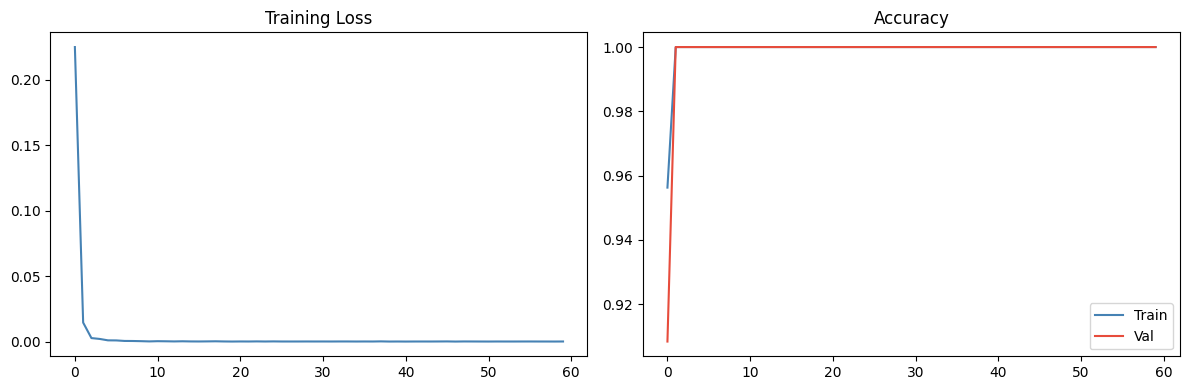

In [3]:
criterion  = nn.CrossEntropyLoss()
optimiser  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=60)
best_acc, best_state = 0.0, None
tr_accs, va_accs, tr_losses = [], [], []
for epoch in range(60):
    model.train()
    correct_tr, total_tr, ep_loss = 0, 0, []
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimiser.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward(); optimiser.step()
        ep_loss.append(loss.item())
        correct_tr += (out.argmax(1) == yb).sum().item()
        total_tr   += len(yb)
    scheduler.step()
    model.eval()
    with torch.no_grad():
        va_out  = model(X_va.to(device))
        va_acc  = (va_out.argmax(1) == y_va.to(device)).float().mean().item()
    tr_accs.append(correct_tr / total_tr)
    va_accs.append(va_acc)
    tr_losses.append(np.mean(ep_loss))
    if va_acc > best_acc:
        best_acc = va_acc; best_state = deepcopy(model.state_dict())
model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_acc:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_losses, color='steelblue'); axes[0].set_title('Training Loss')
axes[1].plot(tr_accs, label='Train', color='steelblue')
axes[1].plot(va_accs, label='Val',   color='#e74c3c')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Feature Map Visualisation

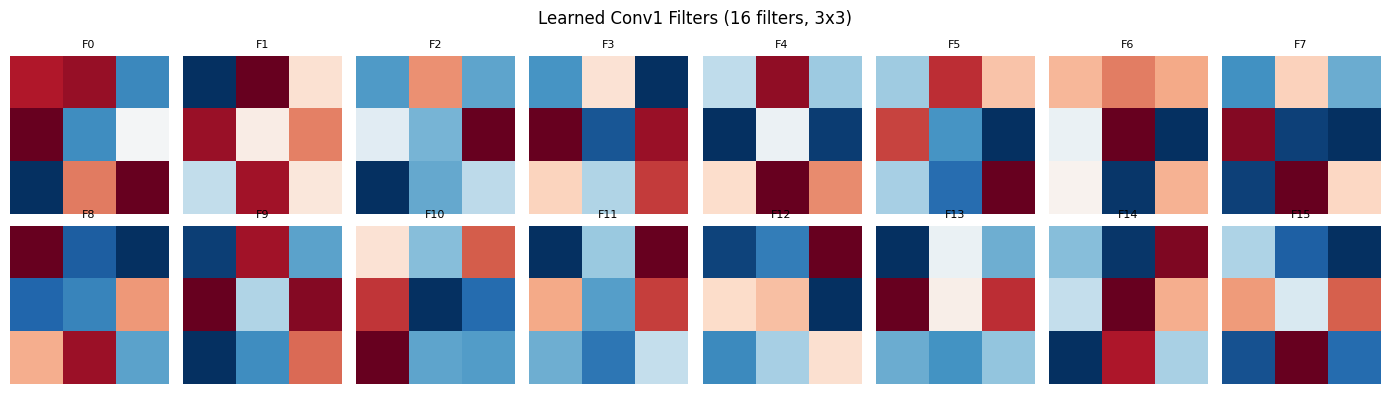

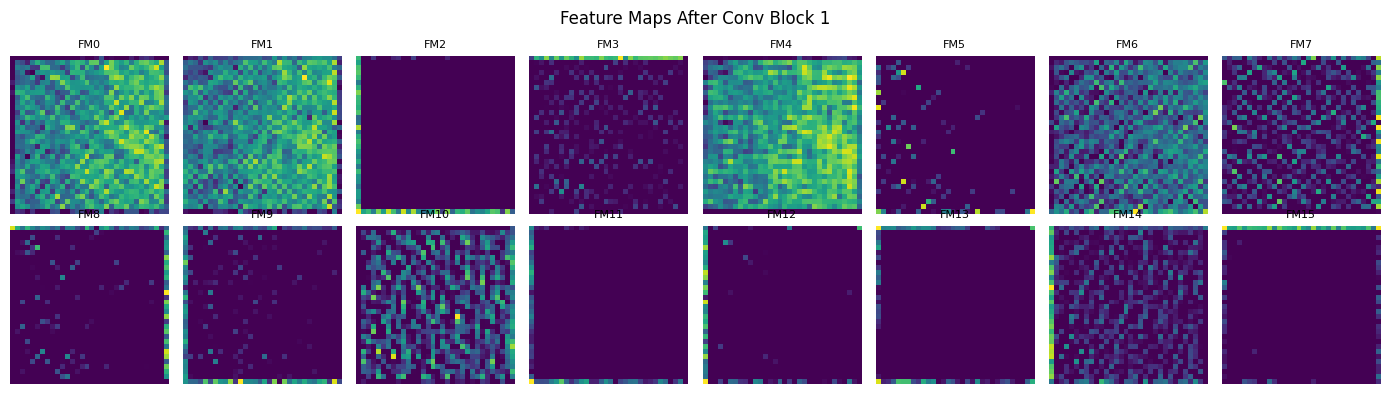

In [4]:
# Visualise what the first conv layer learned
first_conv_weights = model.features[0].weight.data.cpu()
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.ravel()):
    if i < first_conv_weights.shape[0]:
        ax.imshow(first_conv_weights[i, 0], cmap='RdBu_r')
        ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned Conv1 Filters (16 filters, 3x3)')
plt.tight_layout(); plt.show()

# Feature maps for a sample image
model.eval()
sample = X_va[:1].to(device)
with torch.no_grad():
    feat_maps = model.features[:3](sample)   # after conv1+bn+relu
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.ravel()):
    if i < feat_maps.shape[1]:
        ax.imshow(feat_maps[0, i].cpu(), cmap='viridis')
        ax.set_title(f'FM{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Feature Maps After Conv Block 1')
plt.tight_layout(); plt.show()

In [5]:
# 1D CNN for time-series data (same principles, different dimensions)
class CNN1D(nn.Module):
    def __init__(self, in_channels=1, n_classes=2, seq_len=48):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.AdaptiveAvgPool1d(8),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(32*8, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.head(self.conv(x))

# Simulate multivariate time series: 48 time steps, 3 sensors
n_ts = 400
X_ts = torch.from_numpy(rng.normal(0, 1, (n_ts, 3, 48)).astype(np.float32))
y_ts = torch.randint(0, 2, (n_ts,))
cnn1d = CNN1D(in_channels=3, seq_len=48).to(device)
out_1d = cnn1d(X_ts[:8].to(device))
print(f"1D CNN: input {X_ts[:8].shape} -> output {out_1d.shape}")
print(f"Parameters: {sum(p.numel() for p in cnn1d.parameters()):,}")
print("\nCNN1D pattern identical to CNN2D -- only kernel/pool dimensions differ")

1D CNN: input torch.Size([8, 3, 48]) -> output torch.Size([8, 2])
Parameters: 18,498

CNN1D pattern identical to CNN2D -- only kernel/pool dimensions differ


---

## Common Pitfalls

**1. Not using `padding` in convolutional layers**  
Without padding, each 3×3 convolution reduces spatial dimensions by 2 pixels per side. A 32×32 input collapses to nothing after ~15 layers, preventing deep networks. Use `padding=1` with `kernel_size=3` (or `padding="same"`) to maintain spatial dimensions across a block.

**2. Using `MaxPool` without accounting for its effect on feature map size**  
Each `MaxPool2d(2)` halves spatial dimensions. An input of 32×32 becomes 16×16 → 8×8 → 4×4 after three pools. If you then specify a `Linear` layer expecting a fixed flattened size, a different input resolution silently produces a shape mismatch. Use `AdaptiveAvgPool2d` in the final spatial block to decouple feature extraction from input resolution.

**3. Placing BatchNorm after ReLU instead of before**  
The standard ordering is Conv → BatchNorm → ReLU. BatchNorm normalises the pre-activation distribution, which works best before the non-linearity. Placing it after ReLU discards the negative half of the distribution before normalisation.

**4. Using `CrossEntropyLoss` with one-hot targets instead of class indices**  
PyTorch's `CrossEntropyLoss` expects integer class indices (shape `(N,)`), not one-hot vectors (shape `(N, C)`). Passing one-hot targets causes a shape mismatch or silently wrong gradients. Use `torch.argmax` to convert one-hot to indices if needed.

**5. Not normalising input images to [0,1] or standardising per channel**  
Unormalised pixel values (0–255) produce very large activations and large gradients in the first layer, destabilising training. Always normalise image inputs to [0,1] (divide by 255) or standardise per channel with ImageNet statistics (`mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]`) when using pretrained models.

---
*python_methods_library - Samantha McGarrigle*